# Telco Customer Churn exercise
As mentioned in the [designated Kaggle entry](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download):
- Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs

The extra information provided on the data set:
- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

On the first place we will proceed to import all of the different libraries we will need:

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import copy
from sklearn.metrics import silhouette_score

Now we proceed to visualize our .csv file using the _pandas_ library:

In [4]:
dataframe = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
dataframe

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
print(dataframe.shape)
print(dataframe.info())
print(dataframe.describe())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


Due to the absence of information pending of classification, it would be needed to use non-supervised training methods to extract information from the data set.

We will preprocess the information of the dataset to then apply non-supervised training with the objective of clustering the information. We will use the KMeans method.

## First iteration
### Preprocessing
We start the pre-processing by removing the ID of each of the people, as this are irrelevant to the analysis.

In [6]:
dataframe = dataframe.drop(columns=["customerID"])

To avoid any kind of conflict with the next step, all those columns that correspond to numerical values will be transformed (if they are labeled as strings, which is the case of TotalCharges):

In [7]:
dataframe["TotalCharges"] = pd.to_numeric(
    dataframe["TotalCharges"],
    errors="coerce"
)

Now we will transform the categorical variables into more machine learning friendly columns. For this purpose the "get_dummies" function from the "pandas" library will be used, as well as the "drop_first" option in this function.

Basically, what we pretend with this process is classifying columns like PaymentMethod, in which there are various possible answers, into a certain number of columns, each assigned to a possible answer, in which "pandas" writes Yes/No if the that is the answer featured in that case. The option "drop_first" eliminates one of the columns assigned to one of the possible answers due to the fact that it can be extracted from the rest of the other answers if that is the one that existed in that line.

In [8]:
dataframe = pd.get_dummies(dataframe, drop_first=True)
dataframe = dataframe.dropna()
dataframe_copy = copy.deepcopy(dataframe)
dataframe = dataframe.drop(columns=["Churn_Yes"])

Finally, as part of our preprocessing we will use the StandardScaler function of "scikit-learn", which will apply the following formula to our dataset:
$$
z = (x - u) / s
$$
Therefore, we will have all of our variables normalized into mean = 0 (u) and standard deviation = 1 (s) based on the mean and the standard deviation of each variable.

The process will return an array containing all the information but modified into smaller numbers to make it more manageable.

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(dataframe)
X

array([[-0.44032709, -1.28024804, -1.16169394, ..., -0.5253508 ,
         1.40476387, -0.54360352],
       [-0.44032709,  0.06430269, -0.26087792, ..., -0.5253508 ,
        -0.71186341,  1.83957601],
       [-0.44032709, -1.23950408, -0.36392329, ..., -0.5253508 ,
        -0.71186341,  1.83957601],
       ...,
       [-0.44032709, -0.87280842, -1.17000405, ..., -0.5253508 ,
         1.40476387, -0.54360352],
       [ 2.27103902, -1.15801615,  0.31916782, ..., -0.5253508 ,
        -0.71186341,  1.83957601],
       [-0.44032709,  1.36810945,  1.35793167, ..., -0.5253508 ,
        -0.71186341, -0.54360352]], shape=(7032, 30))

### Clustering
We will now start applying the KMeans clustering method. However, this method needs of a number of clusters to search for on the dataset that must be previously stablished. Therefore we will proceed to use the Elbow Method, which consists on applying the KMeans algorithm to the dataset with an increasing number of clusters until one reaches the point in which the error is no longer lowered.

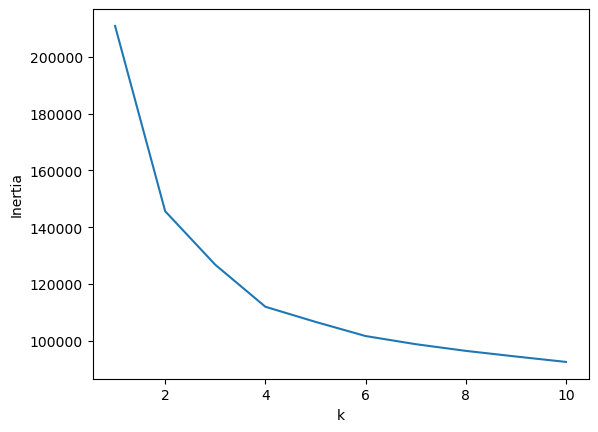

In [10]:
inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

It can be clearly concluded that the inertia reaches a decent enough result with 6 clusters, therefore we apply this parameter (or higher) to the KMeans clustering method:

In [11]:
kmeans = KMeans(
    n_clusters=2,
)
clusters = kmeans.fit_predict(X)

Now we append a column to our dataset in which we represent the cluster to which each of the data belongs, therefore allowing us to perform different types of observations:

In [12]:
dataframe_copy["Cluster"] = clusters
dataframe_copy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,Cluster
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,True,False,False,True,True,0
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,True,False,True,False,False,True,False,0
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,True,False,True,True,False,False,False,0
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,True,False,True,False,False,0
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,True,False,False,True,True,0


First, we use the "groupby" method to classify our dataset depending on the cluster it belongs to, as well as the "mean" method to visualize the mean value of the desired variable on each of the different clusters.

In [13]:
dataframe_copy.groupby("Cluster").mean()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.197750,32.905479,76.855053,2729.505406,0.503447,0.482583,0.265239,0.876633,0.123367,0.476597,...,0.490385,0.0,0.495464,0.201197,0.190856,0.675435,0.215893,0.406930,0.157656,0.318578
1,0.034211,30.667763,21.076283,665.220329,0.509211,0.482237,0.419079,1.000000,0.000000,0.223684,...,0.000000,1.0,0.000000,0.238816,0.416447,0.292763,0.217763,0.080263,0.483553,0.074342


We may as well use PCA (Principal Components Analysis) to plot the results:

In [14]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

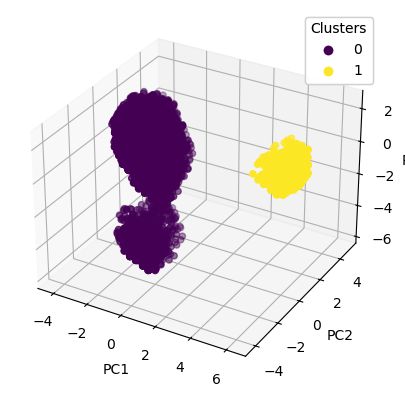

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter3D(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters,
    cmap="viridis"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Clusters"
)
ax.add_artist(legend)

plt.show()

Now we will focus on extracting more information about our results and their certainty. For this purpose we will evaluate, in the first place, the size of each cluster:

In [16]:
dataframe_copy["Cluster"].value_counts().sort_index()

Cluster
0    5512
1    1520
Name: count, dtype: int64

Now we will obtain the silhoutte score from the results. 

The silhoutte score allows us to verify if the different points are correctly grouped inside their cluster and adequately separated from the rest of the clusters. The higher it is the more correcly separated the different groups are, resulting on a more exact clustering. When one has a lower or higher number of clusters than the ideal it is normal for the silhoutte score to decrease.

In our case:

In [17]:
for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
    )
    clusters = kmeans.fit_predict(X)
    score = silhouette_score(X, clusters)
    print(f"Silhoutte score for {i} clusters: {score}")


Silhoutte score for 2 clusters: 0.33510045574519265
Silhoutte score for 3 clusters: 0.21938756320600342
Silhoutte score for 4 clusters: 0.23913459025236608
Silhoutte score for 5 clusters: 0.19783103390612813
Silhoutte score for 6 clusters: 0.13631854983366948
Silhoutte score for 7 clusters: 0.1380934665252298
Silhoutte score for 8 clusters: 0.13166182303688398
Silhoutte score for 9 clusters: 0.12520717243288418
Silhoutte score for 10 clusters: 0.17577910179376036


Finalmente obtenemos los resultados sobre la cantidad de información que está siendo representada por la PCA:

In [18]:
sum(pca.explained_variance_ratio_[:3])

np.float64(0.5418373590861703)

Como se puede ver, se puede concluir que solamente se está visualizando el 54% de la información.

It can be clearly seen that the Silhoutte Score which should be more than 0.7 to be considered a good result, doesn't reach the bare minimum to be considered even remotely good. It can also be concluded that 2 is the ideal number of clusters for our case, it being clear from the PCA based plot.

## Second iteration
### Preprocessing
In this case we will follow the same procedure as in the First iteration, but some fundamental changes will be made:
- We will investigate each of the columns to avoid any kind of repeated information:
    - In this case, employing the TotalCharges column is redundant due to it summarizing the MonthlyCharges and Payments columns.
- We will apply a PCA to reduce the number of columns.
    - We will use a PCA that reduces the number of columns until we reach an explained variance ratio of at least 85%.

In [19]:
dataframe = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
dataframe = dataframe.drop(columns=["customerID", "TotalCharges"])
dataframe = pd.get_dummies(dataframe, drop_first=True)
dataframe = dataframe.dropna()
dataframe_copy = copy.deepcopy(dataframe)
dataframe = dataframe.drop(columns=["Churn_Yes"])
print(dataframe.info())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe)
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)
print(sum(pca.explained_variance_ratio_))
print(pca.n_components_)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   gender_Male                            7043 non-null   bool   
 4   Partner_Yes                            7043 non-null   bool   
 5   Dependents_Yes                         7043 non-null   bool   
 6   PhoneService_Yes                       7043 non-null   bool   
 7   MultipleLines_No phone service         7043 non-null   bool   
 8   MultipleLines_Yes                      7043 non-null   bool   
 9   InternetService_Fiber optic            7043 non-null   bool   
 10  InternetService_No                     7043 non-null   bool   
 11  OnlineSecurity_

Therefore, we have effectively reduced the number of columns from a total of 24 to only 12 which contain at least 85% of the information featured in the original set.

### Clustering
Once we have obtained our processed data set we are able to apply the same clustering method as the previous iteration:

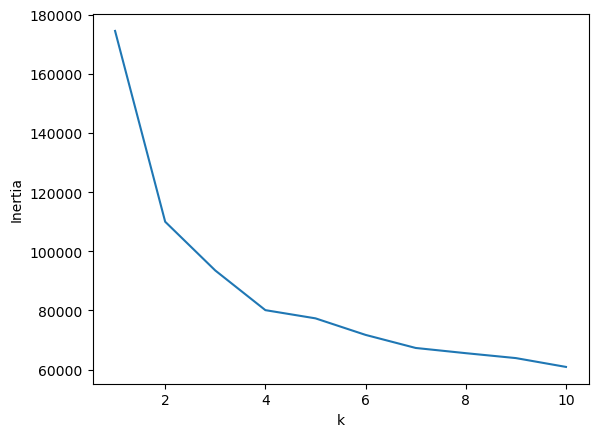

In [20]:
inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=2,
)
clusters = kmeans.fit_predict(X_pca)
dataframe_copy["Cluster"] = clusters
cluster_profile = dataframe_copy.groupby("Cluster").mean()


In [26]:
dataframe_copy['Cluster'].value_counts(normalize=True)*100

Cluster
0    78.333097
1    21.666903
Name: proportion, dtype: float64

In [30]:
centroids = cluster_profile

diff = abs(centroids.loc[0] - centroids.loc[1])
diff.sort_values(ascending=False).head(10)

MonthlyCharges                          55.765060
tenure                                   2.328475
OnlineBackup_No internet service         1.000000
InternetService_No                       1.000000
OnlineSecurity_No internet service       1.000000
DeviceProtection_No internet service     1.000000
StreamingTV_No internet service          1.000000
StreamingMovies_No internet service      1.000000
TechSupport_No internet service          1.000000
InternetService_Fiber optic              0.561175
dtype: float64

Now we evaluate using the silhoutte score:

In [22]:
for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
    )
    clusters = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, clusters)
    print(f"Silhoutte score for {i} clusters: {score}")


Silhoutte score for 2 clusters: 0.39793728052192584
Silhoutte score for 3 clusters: 0.3439104448787172
Silhoutte score for 4 clusters: 0.26345044029293885
Silhoutte score for 5 clusters: 0.22703476059451586
Silhoutte score for 6 clusters: 0.2173993048156281
Silhoutte score for 7 clusters: 0.17191042846678609
Silhoutte score for 8 clusters: 0.16817028988013646
Silhoutte score for 9 clusters: 0.1626079369707618
Silhoutte score for 10 clusters: 0.16822411682752925


It is clear that the best way to cluster the information is using 2 clusters, which coincides with the first iteration. However, with the preprocessing of this second iteration we are able to obtain a better silhoutte score by ~6%, which is not close to the best possible outcome, but is a functional result.

## Conclusions on the dataset

### Cluster "0": High value and high risk clients
- They pay mucho more than the rest
- They request more services
- High churn probability

#### Acciones
- Fidelity programs
- Personalized discounts
- Identify abandon causes
### Cluster "1": Basic and stable clients
- Low income per client
- Low churn rate
- Longer contracts

#### Acciones

- Upsell internet or streaming to increase
- Trying to increase average revenue per user